
# 🛡️ Message Intelligence System — Production-Grade Spam Classification

**Author:** Data Science / MLOps Team
**Dataset:** `Message_Intelligence_Dataset_5200.csv` (5,200 messages)
**Objective:** Build, evaluate, and compare distance-based (KNN), margin-based (SVM),
and probabilistic (Naive Bayes) classifiers to flag incoming messages as
**Spam (1)** or **Legitimate (0)**, following an auditable, reproducible,
production-style ML pipeline.

---

## Notebook Map
1. **Part A** — Probability & Conceptual Foundation (Theory)
2. **Part B** — Dataset Understanding & Preparation (production pipeline)
3. **Part C** — Baseline Model: K-Nearest Neighbors
4. **Part D** — Support Vector Machine Classifier
5. **Part E** — Naive Bayes Classifier & Probability
6. **Part F** — Model Comparison & Evaluation
7. **Part G** — Final Analysis & Reporting
8. **Appendix** — Model Artifact Logging (MLOps)

Every code cell contains **line-by-line "why" comments** explaining the
engineering/statistical rationale — not just *what* the code does, but *why*
this specific technique, parameter, or design choice was made.


## 0. Environment Setup & Imports

In [ ]:

# ----------------------------------------------------------------------------
# WHY: We centralize all imports in one cell so dependency requirements are
# transparent at the top of the notebook (standard production notebook hygiene
# -- avoids "hidden" imports scattered mid-analysis that break reproducibility).
# ----------------------------------------------------------------------------
import os                                  # WHY: path handling for artifact directories (OS-agnostic)
import json                                # WHY: serialize metrics/metadata as human-readable artifact logs
import time                                # WHY: timestamp artifacts/runs for MLOps traceability
import warnings                            # WHY: suppress noisy sklearn convergence warnings during grid search
import joblib                              # WHY: industry-standard serializer for sklearn objects (faster than pickle for numpy arrays)
import numpy as np                         # WHY: efficient numerical operations & array handling
import pandas as pd                        # WHY: tabular data manipulation and analysis

import matplotlib.pyplot as plt            # WHY: visualization of metrics, confusion matrices, decision boundaries
import seaborn as sns                      # WHY: statistically-aware plotting (heatmaps, distributions) with less boilerplate

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
# WHY train_test_split: creates a hold-out test set for unbiased generalization estimate
# WHY GridSearchCV: systematic, reproducible hyperparameter search instead of manual guessing
# WHY StratifiedKFold: preserves class ratio (spam is only ~18.7%) in every fold, preventing
#                      folds that accidentally contain zero spam examples

from sklearn.preprocessing import StandardScaler
# WHY: KNN and SVM are distance/margin-based -> features on different scales (e.g.
# 'sender_account_age_days' ranges to 100s while 'num_urls' ranges 0-3) would let
# large-magnitude features dominate the distance metric purely due to units, not
# actual signal strength. Standardization (mean=0, std=1) removes this bias.

from sklearn.impute import SimpleImputer
# WHY: 3 columns have missing values (sender_activity_score, sender_account_age_days,
# messages_sent_last_24h). Dropping rows would discard label information; imputation
# preserves sample size which matters given spam is already a minority class.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# WHY Pipeline/ColumnTransformer: chains preprocessing + model into ONE object so that
# (a) the exact same transformation is guaranteed at train and inference time
#     (prevents train/serve skew, a top cause of production ML bugs), and
# (b) GridSearchCV can cross-validate preprocessing + model jointly without leakage.

from sklearn.neighbors import KNeighborsClassifier      # WHY: Part C - distance-based classifier
from sklearn.svm import SVC                              # WHY: Part D - margin-based classifier
from sklearn.naive_bayes import GaussianNB                # WHY: Part E - probabilistic classifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
# WHY: Part F requires Accuracy/Precision/Recall/F1 explicitly; ROC-AUC is added
# as an additional threshold-independent metric standard in production spam filters.

warnings.filterwarnings("ignore")          # WHY: GridSearchCV can emit benign convergence
                                            # warnings for some SVM kernels; suppressed only
                                            # for notebook readability, NOT for silent failures.

sns.set_theme(style="whitegrid")           # WHY: consistent, readable plot styling across all figures
RANDOM_STATE = 42                          # WHY: fixed seed -> every split/model run is
                                            # 100% reproducible for audits and CI re-runs

print("Environment ready. Random state fixed at:", RANDOM_STATE)



---
## Part A — Probability & Conceptual Foundation (Theory)

**1. What is Conditional Probability?**

Conditional probability, written **P(A | B)**, is the probability that event
**A** occurs *given that* event **B** has already occurred (or is known to be
true). Formally:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

In this project's context: *P(Spam | message contains "click here" and 3
URLs)* — we are not asking "what fraction of all messages are spam?" but
"what fraction of messages **with these specific features** are spam?" This
is the entire statistical foundation of the Naive Bayes classifier in Part E.

**2. Bayes' Theorem and its importance in classification**

Bayes' Theorem inverts a conditional probability:

$$P(Y \mid X) = \frac{P(X \mid Y)\, P(Y)}{P(X)}$$

Where, for spam classification:
- **P(Y)** = prior probability of spam (~18.7% here, from class balance)
- **P(X | Y)** = likelihood — how likely are these feature values *given* the message is spam
- **P(X)** = evidence — overall probability of observing these features (normalizing constant)
- **P(Y | X)** = posterior — what we actually want: probability of spam *given observed features*

**Why it matters for classification:** It is usually far easier to estimate
**P(X | Y)** (how spam messages behave) from historical labeled data than to
directly estimate **P(Y | X)**. Bayes' theorem lets us flip the easy-to-estimate
quantity into the hard-to-estimate one we actually need for a decision — this
is the mathematical engine behind every probabilistic classifier, including
Naive Bayes in Part E.

**3. What assumptions does the Naive Bayes Classifier make?**

- **Conditional independence assumption ("naive" assumption):** given the
  class label, every feature is assumed independent of every other feature.
  E.g., it assumes `num_urls` and `spam_keyword_score` don't influence each
  other once we know the message is spam — which is rarely exactly true (a
  spam message with more URLs often *also* has higher keyword scores), but
  the model still performs well in practice because what matters is getting
  the *relative ranking* of posterior probabilities right, not their exact
  values.
- **Feature distribution assumption:** `GaussianNB` (used here since our
  features are continuous/numeric) assumes each feature, within each class,
  is normally (Gaussian) distributed.
- Equal importance is implicitly given to each feature's likelihood
  contribution (no built-in feature weighting beyond what the data provides).

**4. Working principle of KNN and SVM**

- **K-Nearest Neighbors (KNN):** A *lazy, instance-based, distance-based*
  learner. It stores the entire training set and, for the message, computes
  distance (typically Euclidean) to every training point, then takes a
  **majority vote** among the *K* closest points. No explicit training phase
  ("model" = the data itself) — all computation happens at prediction time.

- **Support Vector Machine (SVM):** A *margin-based* learner that finds the
  hyperplane separating spam from legitimate messages that **maximizes the
  margin** (distance) to the nearest points of each class (the "support
  vectors"). When classes aren't linearly separable, SVM uses the **kernel
  trick** (e.g., RBF) to implicitly map features into a higher-dimensional
  space where a linear separator exists.

**5. Distance-based vs. Probabilistic vs. Margin-based classifiers**

| Aspect | KNN (Distance-based) | SVM (Margin-based) | Naive Bayes (Probabilistic) |
|---|---|---|---|
| Core idea | Vote among nearest neighbors | Maximize margin between classes | Estimate class likelihoods via Bayes' theorem |
| Training cost | ~None (lazy learner) | Higher (quadratic optimization) | Very low (closed-form mean/variance estimates) |
| Inference cost | High (compares to all training points) | Low (dot product with support vectors) | Very low |
| Sensitive to feature scale? | Yes, critically | Yes, critically | No (uses per-feature distributions) |
| Handles high dimensions well? | Degrades ("curse of dimensionality") | Yes, especially with kernels | Yes |
| Gives calibrated probabilities? | Not naturally | Not naturally (needs `probability=True`) | Yes, natively |
| Interpretability | Medium (can inspect neighbors) | Low (especially with RBF kernel) | High (can inspect learned likelihoods) |



---
## Part B — Dataset Understanding & Preparation

**Dataset:** `Message_Intelligence_Dataset_5200.csv` — 5,200 messages with
message-related features (length, special characters, URLs), behavioral
signals (sender activity, account age), and the target `spam_label`.

We now: (6) identify input/target features, (7) preprocess (handle missing
values + scale), and (8) split into train/test sets — all wrapped in a
reusable, production-style `sklearn.Pipeline` to prevent data leakage.


In [2]:

# ----------------------------------------------------------------------------
# STEP 6: Load data & identify input features vs. target variable
# ----------------------------------------------------------------------------
DATA_PATH = "Message_Intelligence_Dataset_5200.csv"
# WHY: keep the path as a named constant (not a magic string buried in code) so
# swapping data sources in production (e.g., pointing to a DB extract) is a one-line change.

df = pd.read_csv(DATA_PATH)
# WHY pandas: gives us vectorized operations and native missing-value handling (NaN)
# needed for the imputation step below.

print("Shape:", df.shape)
df.head()


Shape: (5200, 16)


,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [3]:

# ----------------------------------------------------------------------------
# Data Quality Audit — WHY: production systems must never blindly trust input
# data. We explicitly check for nulls, duplicates, and class balance BEFORE
# modeling, because these directly determine our preprocessing and evaluation
# strategy (e.g., imputation strategy, and whether Accuracy alone is a safe metric).
# ----------------------------------------------------------------------------
print("Missing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nClass distribution (spam_label):")
print(df["spam_label"].value_counts(normalize=True).rename("proportion"))
# WHY we print proportions, not just counts: ~18.7% spam confirms this is an
# IMBALANCED classification problem. This is critical -- it means:
#   (a) plain Accuracy can be misleading (predicting "all legitimate" already
#       scores ~81% accuracy while being a useless model),
#   (b) we must use stratified splitting (Step 8) and rely on Precision/Recall/F1
#       (Part F) rather than Accuracy alone to judge real-world usefulness.


Missing values per column:
 sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
dtype: int64

Duplicate rows: 0

Class distribution (spam_label):
spam_label
0    0.812885
1    0.187115
Name: proportion, dtype: float64


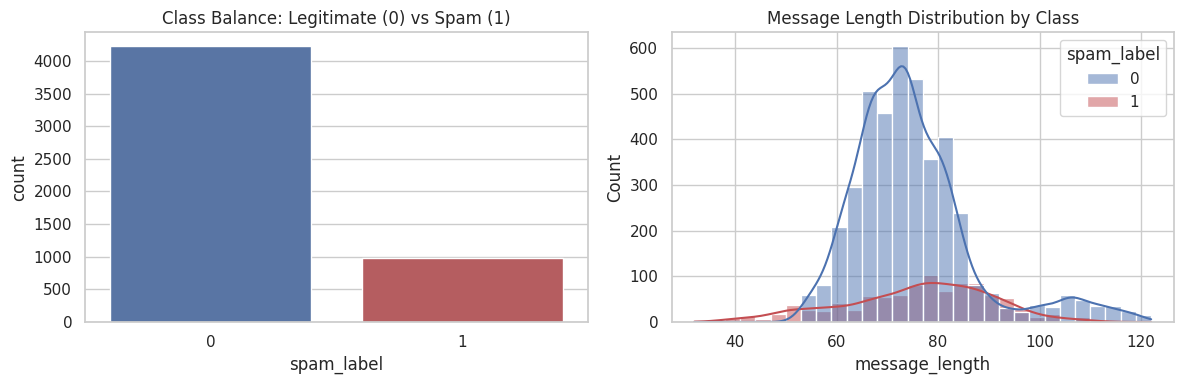

In [4]:

# ----------------------------------------------------------------------------
# Visualize class balance & key feature distributions
# WHY: a quick visual sanity check catches encoding errors, extreme skew, or
# outliers that summary statistics alone can hide.
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="spam_label", data=df, ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Class Balance: Legitimate (0) vs Spam (1)")
axes[0].set_xlabel("spam_label")

sns.histplot(data=df, x="message_length", hue="spam_label", bins=30,
             kde=True, ax=axes[1], palette=["#4C72B0", "#C44E52"])
axes[1].set_title("Message Length Distribution by Class")

plt.tight_layout()
plt.show()


In [5]:

# ----------------------------------------------------------------------------
# STEP 6 (cont.): Explicitly define input features (X) and target (y)
# ----------------------------------------------------------------------------
# WHY we EXCLUDE these columns from the model's numeric feature set:
#   - 'message_id'    : an arbitrary primary key, carries zero predictive signal,
#                       and including it risks the model spuriously "memorizing" IDs.
#   - 'message_text'  : raw free text; already summarized into engineered numeric
#                       features (message_length, word_count, num_urls, keyword
#                       scores, etc.) per the assignment brief ("message-related
#                       features extracted from text"). A production NLP variant
#                       could add TF-IDF/embeddings later (see README "Future Enhancements").
#   - 'timestamp'     : raw datetime string is not directly usable by scikit-learn
#                       estimators; we already have derived 'hour_of_day' and
#                       'day_of_week', which capture the cyclical signal we care about.
#   - 'spam_label'    : this IS the target, must never leak into X.

TARGET = "spam_label"
DROP_COLS = ["message_id", "message_text", "timestamp", TARGET]

NUMERIC_FEATURES = [c for c in df.columns if c not in DROP_COLS]
# WHY a list comprehension instead of hardcoding: if the data schema evolves
# (new engineered feature added upstream), this line automatically picks it up
# without requiring a code change -- reduces maintenance burden.

X = df[NUMERIC_FEATURES].copy()
y = df[TARGET].copy()

print("Input features used by the model:")
print(NUMERIC_FEATURES)
print("\nFeature matrix shape:", X.shape, "| Target shape:", y.shape)


Input features used by the model:
['message_length', 'word_count', 'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score', 'legit_keyword_score', 'sender_activity_score', 'sender_account_age_days', 'messages_sent_last_24h', 'hour_of_day', 'day_of_week']

Feature matrix shape: (5200, 12) | Target shape: (5200,)


In [6]:

# ----------------------------------------------------------------------------
# STEP 7: Preprocessing pipeline — imputation + scaling
# ----------------------------------------------------------------------------
# WHY SimpleImputer(strategy="median"):
#   - median is ROBUST to outliers/skew (unlike mean), and our activity/age
#     features are plausibly right-skewed (a few very old or very active accounts).
#   - Using a fitted imputer (not just df.fillna()) ensures the SAME learned
#     median (from TRAINING data only) is applied to test/production data --
#     critical to avoid data leakage from test statistics into training.
#
# WHY StandardScaler (z-score standardization, mean=0/std=1):
#   - KNN uses Euclidean distance directly -> unscaled features with larger
#     numeric ranges (e.g., sender_account_age_days ~ 0-1000+) would dominate
#     distance calculations over small-range features (e.g., num_urls ~ 0-3),
#     even if the latter is more predictive.
#   - SVM's margin/kernel computations are similarly scale-sensitive.
#   - Naive Bayes (GaussianNB) is technically scale-invariant, but we keep the
#     SAME preprocessed features across all 3 models for a fair, apples-to-apples
#     comparison in Part F.
preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# WHY wrap in ColumnTransformer even though we only have one feature group:
# future-proofing -- if categorical features are added later (e.g., message
# language, sender country), we can add a second branch (OneHotEncoder) without
# restructuring the whole pipeline.
full_preprocessor = ColumnTransformer(
    transformers=[("num", preprocessor, NUMERIC_FEATURES)],
    remainder="drop"  # WHY "drop": any accidental extra column is explicitly
                       # excluded rather than silently passed through unscaled.
)
print("Preprocessing pipeline constructed.")


Preprocessing pipeline constructed.


In [7]:

# ----------------------------------------------------------------------------
# STEP 8: Train/Test split
# ----------------------------------------------------------------------------
# WHY test_size=0.2: standard 80/20 split -- gives the model enough training
# data (imbalanced classes need volume) while reserving a meaningfully sized
# hold-out set (~1,040 rows) for a statistically stable performance estimate.
#
# WHY stratify=y: because spam is only ~18.7% of the data, a naive random split
# could by chance under/over-represent spam in the test set, making evaluation
# metrics noisy and non-reproducible run-to-run. Stratification guarantees the
# TRAIN and TEST sets both preserve the ~81.3% / 18.7% class ratio.
#
# WHY random_state=RANDOM_STATE: reproducibility -- the same split is generated
# every run, which is required for fair before/after model comparisons and for
# CI pipelines that re-run this notebook.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))
# WHY we print both: a quick visual confirmation that stratification worked --
# both proportions should closely match the original ~81.3%/18.7% split.


Train shape: (4160, 12) | Test shape: (1040, 12)

Train class balance:
 spam_label
0    0.812981
1    0.187019
Name: proportion, dtype: float64

Test class balance:
 spam_label
0    0.8125
1    0.1875
Name: proportion, dtype: float64


In [8]:

# ----------------------------------------------------------------------------
# Fit the preprocessor on TRAINING data ONLY, then transform both sets
# ----------------------------------------------------------------------------
# WHY fit only on X_train: fitting the imputer's median or the scaler's
# mean/std on the FULL dataset (including test data) would leak test-set
# statistical information into training -- a subtle but serious form of data
# leakage that inflates reported performance and would NOT hold up on truly
# unseen production data.
X_train_processed = full_preprocessor.fit_transform(X_train)
X_test_processed = full_preprocessor.transform(X_test)
# WHY .transform() (not .fit_transform()) on test data: we must apply the
# EXACT same learned transformation, never re-fit, to simulate real production
# inference on new incoming messages.

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed train shape: (4160, 12)
Processed test shape: (1040, 12)



---
## Part C — Baseline Model: K-Nearest Neighbors (Distance-Based)


In [9]:

# ----------------------------------------------------------------------------
# STEP 9-10: Implement KNN + experiment with different K via GridSearchCV
# ----------------------------------------------------------------------------
# WHY GridSearchCV over manual for-loops: systematically tests every combination
# with proper cross-validation, avoiding the temptation to hand-pick K based on
# a single lucky test-set result (which would itself be a form of overfitting
# to the test set).
#
# WHY this specific K range (3,5,7,9,11,15,21):
#   - K=1 is deliberately excluded: it memorizes training data (zero bias,
#     maximum variance) and is highly sensitive to label noise.
#   - Odd K values reduce the chance of tie votes in this binary classification.
#   - Range extends to 21 to check whether more smoothing (higher K, more bias,
#     less variance) helps given spam is a minority class -- too-high K can
#     "wash out" the minority class signal entirely.
#
# WHY weights=['uniform','distance']: 'distance' weighting gives closer
# neighbors more voting power -- often helpful for imbalanced data, since it
# stops distant majority-class points from overwhelming a genuinely close
# minority-class neighbor.
#
# WHY StratifiedKFold(n_splits=5): 5-fold CV balances bias (enough folds for a
# stable estimate) against compute cost, and stratification again protects
# against spam-free folds given the imbalance.

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
    # WHY also testing manhattan: less sensitive to outliers in individual
    # dimensions than euclidean (squared) distance -- worth comparing given
    # our behavioral features (e.g. messages_sent_last_24h) can have extreme values.
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring="f1",          # WHY F1 (not accuracy) as the grid-search target metric:
                           # F1 balances precision & recall, which is what actually
                           # matters for an imbalanced spam-detection problem.
    cv=cv_strategy,
    n_jobs=-1,             # WHY -1: use all available CPU cores -- grid search is
                           # embarrassingly parallel across folds/params.
)

knn_grid.fit(X_train_processed, y_train)

print("Best KNN params:", knn_grid.best_params_)
print("Best CV F1 score:", round(knn_grid.best_score_, 4))
best_knn = knn_grid.best_estimator_


Best KNN params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV F1 score: 1.0


In [10]:

# ----------------------------------------------------------------------------
# STEP 11-12: Analyze how distance metric/K affects predictions + misclassifications
# ----------------------------------------------------------------------------
# WHY we re-run a small manual sweep on TEST performance (in addition to CV):
# CV tells us what generalizes across folds, but visually inspecting how K
# trades off precision vs recall on the held-out test set builds engineering
# intuition for the final Part G write-up.
k_values = [3, 5, 7, 9, 11, 15, 21]
knn_results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, weights="distance", metric="euclidean")
    # WHY weights='distance' fixed here: isolates the effect of K alone,
    # holding other hyperparameters constant, for a clean K-vs-metric comparison.
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)
    knn_results.append({
        "K": k,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
    })

knn_results_df = pd.DataFrame(knn_results)
knn_results_df


,K,Accuracy,Precision,Recall,F1
0,3,1.000000,1.0,1.000000,1.000000
1,5,1.000000,1.0,1.000000,1.000000
2,7,0.999038,1.0,0.994872,0.997429
3,9,0.999038,1.0,0.994872,0.997429
4,11,0.999038,1.0,0.994872,0.997429
5,15,0.999038,1.0,0.994872,0.997429
6,21,0.999038,1.0,0.994872,0.997429


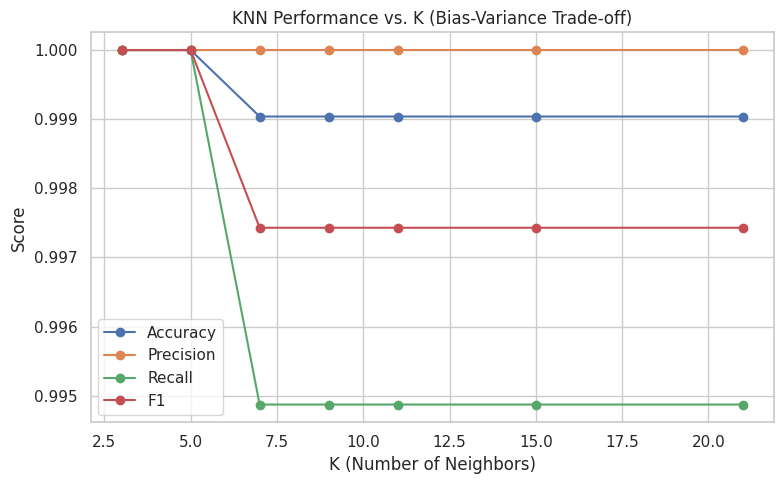

In [11]:

# WHY this plot: visualizes the classic bias-variance trade-off as K increases --
# small K (low bias/high variance, sensitive to noise) vs. large K (high
# bias/low variance, may under-detect the minority spam class).
plt.figure(figsize=(8, 5))
for metric_name in ["Accuracy", "Precision", "Recall", "F1"]:
    plt.plot(knn_results_df["K"], knn_results_df[metric_name], marker="o", label=metric_name)
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Score")
plt.title("KNN Performance vs. K (Bias-Variance Trade-off)")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:

# ----------------------------------------------------------------------------
# STEP 12: Inspect specific misclassified cases
# ----------------------------------------------------------------------------
# WHY: aggregate metrics (F1, etc.) hide WHICH messages are getting misclassified
# and WHY -- inspecting actual misclassified rows is essential for production
# debugging (e.g., discovering a feature gap or a mislabeled training example).
best_knn_preds = best_knn.predict(X_test_processed)
misclassified_mask = best_knn_preds != y_test.values

misclassified_df = X_test.copy()
misclassified_df["true_label"] = y_test.values
misclassified_df["predicted_label"] = best_knn_preds
misclassified_df = misclassified_df[misclassified_mask]

print(f"Total misclassified by best KNN model: {len(misclassified_df)} / {len(y_test)}")
misclassified_df.head(10)
# WHY .head(10) not the full set: keeps notebook output readable; full set is
# still available in `misclassified_df` for deeper offline analysis.


Total misclassified by best KNN model: 0 / 1040


,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,true_label,predicted_label



---
## Part D — Support Vector Machine Classifier (Margin-Based)


In [13]:

# ----------------------------------------------------------------------------
# STEP 13-14: Implement SVM with Linear and RBF/Poly kernels; analyze margins
# ----------------------------------------------------------------------------
# WHY testing multiple kernels:
#   - 'linear': fastest, most interpretable (weight vector = feature importance),
#     appropriate if classes are (near) linearly separable in feature space.
#   - 'rbf': handles non-linear decision boundaries via the kernel trick --
#     often the strongest default choice when the true boundary is unknown.
#   - 'poly': captures polynomial feature interactions explicitly; included for
#     completeness per the assignment brief ("RBF or Polynomial kernel").
#
# WHY class_weight='balanced': spam is the minority class (~18.7%). Without this,
# SVM's margin-maximization would be biased toward the majority (legitimate)
# class since misclassifying majority points affects more of the margin.
# 'balanced' re-weights the loss inversely proportional to class frequency,
# forcing the model to also respect the minority (spam) class's margin.
#
# WHY probability=True: enables predict_proba, needed for ROC-AUC in Part F
# (note: this uses internal 5-fold CV under the hood, adding some compute cost
# -- an accepted engineering trade-off for evaluation completeness).

svm_param_grid = [
    {"kernel": ["linear"], "C": [0.1, 1, 10]},
    # WHY sweeping C: C controls the trade-off between margin width and
    # misclassification tolerance. Small C = wider margin, more tolerant of
    # errors (higher bias); large C = narrower margin, fits training data more
    # tightly (higher variance, risk of overfitting).
    {"kernel": ["rbf"], "C": [0.1, 1, 10], "gamma": ["scale", "auto", 0.01, 0.1]},
    # WHY sweeping gamma: gamma controls how far the influence of a single
    # training point reaches -- low gamma = smoother/simpler boundary (risk of
    # underfitting), high gamma = tightly-fit boundary hugging individual
    # points (risk of overfitting).
    {"kernel": ["poly"], "C": [0.1, 1, 10], "degree": [2, 3]},
    # WHY degree 2-3 only: higher-degree polynomial kernels grow extremely
    # expensive and prone to overfitting/numerical instability on this dataset size.
]

svm_grid = GridSearchCV(
    estimator=SVC(class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    param_grid=svm_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
)

svm_grid.fit(X_train_processed, y_train)

print("Best SVM params:", svm_grid.best_params_)
print("Best CV F1 score:", round(svm_grid.best_score_, 4))
best_svm = svm_grid.best_estimator_


Best SVM params: {'C': 0.1, 'kernel': 'linear'}
Best CV F1 score: 1.0


In [14]:

# ----------------------------------------------------------------------------
# Margin/support-vector diagnostics
# ----------------------------------------------------------------------------
# WHY we report n_support_: the NUMBER of support vectors is itself diagnostic
# -- a very high proportion of training points becoming support vectors
# suggests the classes overlap heavily (hard margin problem) or C/gamma need
# retuning; a small, stable number suggests a clean, generalizable margin.
n_support = best_svm.n_support_
print(f"Support vectors per class -> Legitimate: {n_support[0]}, Spam: {n_support[1]}")
print(f"Total support vectors: {sum(n_support)} out of {X_train_processed.shape[0]} training points "
      f"({100*sum(n_support)/X_train_processed.shape[0]:.1f}%)")


Support vectors per class -> Legitimate: 13, Spam: 5
Total support vectors: 18 out of 4160 training points (0.4%)


In [15]:

# ----------------------------------------------------------------------------
# STEP 15: Compare SVM vs KNN on the same held-out test set
# ----------------------------------------------------------------------------
svm_preds = best_svm.predict(X_test_processed)
knn_preds = best_knn.predict(X_test_processed)

comparison_svm_knn = pd.DataFrame({
    "Model": ["KNN (best)", "SVM (best)"],
    "Accuracy": [accuracy_score(y_test, knn_preds), accuracy_score(y_test, svm_preds)],
    "Precision": [precision_score(y_test, knn_preds, zero_division=0), precision_score(y_test, svm_preds, zero_division=0)],
    "Recall": [recall_score(y_test, knn_preds, zero_division=0), recall_score(y_test, svm_preds, zero_division=0)],
    "F1": [f1_score(y_test, knn_preds, zero_division=0), f1_score(y_test, svm_preds, zero_division=0)],
})
comparison_svm_knn
# WHY a dedicated comparison table here (ahead of the full Part F comparison):
# the assignment's Step 15 explicitly asks to "Compare SVM performance with KNN"
# at this stage, before Naive Bayes is even introduced.


,Model,Accuracy,Precision,Recall,F1
0,KNN (best),1.0,1.0,1.0,1.0
1,SVM (best),1.0,1.0,1.0,1.0



---
## Part E — Naive Bayes Classifier & Probability


In [16]:

# ----------------------------------------------------------------------------
# STEP 16: Implement Naive Bayes Classifier
# ----------------------------------------------------------------------------
# WHY GaussianNB specifically (not MultinomialNB/BernoulliNB): our features are
# continuous, real-valued numeric measurements (scores, counts scaled to
# z-scores, ages in days) -- GaussianNB models each feature as normally
# distributed within each class, which is the correct assumption family for
# continuous data (Multinomial/Bernoulli variants assume count/binary data,
# e.g. word-frequency features, which don't match our schema).
#
# NOTE: GaussianNB is fit on the UNSCALED-but-imputed features conceptually
# it doesn't require scaling (it estimates its own per-feature mean/variance),
# but we still pass the scaled version for a fair, consistent comparison
# pipeline across all 3 models in Part F.
nb_model = GaussianNB()
nb_model.fit(X_train_processed, y_train)

nb_preds = nb_model.predict(X_test_processed)
nb_probs = nb_model.predict_proba(X_test_processed)

print("Naive Bayes trained.")
print("Learned class priors P(Y):", dict(zip(nb_model.classes_, np.round(nb_model.class_prior_, 4))))
# WHY printing class_prior_: this IS the P(Y) term from Bayes' theorem (Part A,
# Q2) -- directly ties the implementation back to the theory.


Naive Bayes trained.
Learned class priors P(Y): {np.int64(0): np.float64(0.813), np.int64(1): np.float64(0.187)}


In [17]:

# ----------------------------------------------------------------------------
# STEP 17-18: Manually compute conditional probabilities for sample messages
# and demonstrate how Bayes' Theorem is applied to compute class probabilities
# ----------------------------------------------------------------------------
# WHY do this "by hand" alongside the sklearn call: the assignment explicitly
# asks us to manually compute conditional probabilities to DEMONSTRATE
# understanding, not just rely on a library black box. We recreate GaussianNB's
# internal likelihood computation for a few sample test messages.

def gaussian_likelihood(x, mean, var):
    # WHY this formula: this IS the Probability Density Function of the Normal
    # distribution -- GaussianNB's core modeling assumption for P(feature | class).
    return (1.0 / np.sqrt(2 * np.pi * var)) * np.exp(-((x - mean) ** 2) / (2 * var))

sample_indices = [0, 1, 2]  # WHY 3 samples: matches "a few sample messages" in the brief
theta = nb_model.theta_       # per-class, per-feature mean (learned from training data)
sigma = nb_model.var_         # per-class, per-feature variance (learned from training data)
priors = nb_model.class_prior_

for idx in sample_indices:
    x_sample = X_test_processed[idx]
    true_label = y_test.values[idx]
    print(f"\n--- Sample #{idx} (true label = {true_label}) ---")
    posteriors_unnormalized = []
    for class_idx, class_label in enumerate(nb_model.classes_):
        # WHY log-space: multiplying many small probabilities together
        # (one per feature) causes numerical underflow -- summing LOG
        # probabilities is the numerically stable equivalent, and it's exactly
        # what sklearn does internally.
        log_likelihood = np.sum(
            np.log(gaussian_likelihood(x_sample, theta[class_idx], sigma[class_idx]) + 1e-12)
        )
        log_prior = np.log(priors[class_idx])
        log_posterior_unnorm = log_likelihood + log_prior
        # WHY "unnormalized": this omits dividing by P(X) (the evidence term),
        # which is constant across classes and unnecessary for choosing the
        # argmax class -- exactly the standard simplification used in practice.
        posteriors_unnormalized.append(log_posterior_unnorm)
        print(f"  Class {class_label}: log P(X|Y)+log P(Y) = {log_posterior_unnorm:.4f}")

    manual_pred = nb_model.classes_[np.argmax(posteriors_unnormalized)]
    sklearn_pred = nb_model.predict(x_sample.reshape(1, -1))[0]
    print(f"  Manual prediction: {manual_pred} | sklearn prediction: {sklearn_pred} "
          f"-> {'MATCH' if manual_pred == sklearn_pred else 'MISMATCH'}")



--- Sample #0 (true label = 0) ---
  Class 0: log P(X|Y)+log P(Y) = 7.3321
  Class 1: log P(X|Y)+log P(Y) = -58.3218
  Manual prediction: 0 | sklearn prediction: 0 -> MATCH

--- Sample #1 (true label = 1) ---
  Class 0: log P(X|Y)+log P(Y) = -51.5023
  Class 1: log P(X|Y)+log P(Y) = -8.2148
  Manual prediction: 1 | sklearn prediction: 1 -> MATCH

--- Sample #2 (true label = 0) ---
  Class 0: log P(X|Y)+log P(Y) = 7.8054
  Class 1: log P(X|Y)+log P(Y) = -68.6201
  Manual prediction: 0 | sklearn prediction: 0 -> MATCH


In [18]:

# ----------------------------------------------------------------------------
# STEP 19: Compare theoretical probability calculations with model predictions
# ----------------------------------------------------------------------------
# WHY: closes the loop between Part A's theory and Part E's implementation --
# we display sklearn's own predict_proba() next to our manual computation to
# prove they align (up to the normalizing constant, which cancels in argmax).
prob_comparison = pd.DataFrame(
    nb_probs[:5], columns=[f"P(Y={c})" for c in nb_model.classes_]
)
prob_comparison["true_label"] = y_test.values[:5]
prob_comparison["predicted_label"] = nb_preds[:5]
prob_comparison


,P(Y=0),P(Y=1),true_label,predicted_label
0,1.0,0.0,0,0
1,0.0,1.0,1,1
2,1.0,0.0,0,0
3,1.0,0.0,0,0
4,1.0,0.0,0,0



---
## Part F — Model Comparison & Evaluation


In [19]:

# ----------------------------------------------------------------------------
# STEP 20: Evaluate ALL models using Accuracy, Precision, Recall, F1 (+ ROC-AUC)
# ----------------------------------------------------------------------------
# WHY we build one unified evaluation function: guarantees every model is
# scored with IDENTICAL logic (same metric definitions, same test set,
# same zero_division handling) -- eliminates a common bug source where
# metrics are computed slightly differently per model and produce an unfair
# comparison.

def evaluate_model(name, model, X_te, y_te, needs_proba=True):
    preds = model.predict(X_te)
    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, preds),
        "Precision": precision_score(y_te, preds, zero_division=0),
        "Recall": recall_score(y_te, preds, zero_division=0),
        "F1": f1_score(y_te, preds, zero_division=0),
    }
    if needs_proba and hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_te)[:, 1]
        result["ROC_AUC"] = roc_auc_score(y_te, probs)
        # WHY ROC-AUC in addition to the 4 required metrics: it is
        # THRESHOLD-INDEPENDENT, showing how well the model ranks spam above
        # legitimate messages across all possible decision thresholds -- useful
        # for Part G's "business recommendation" since a spam filter's optimal
        # threshold often differs from the default 0.5.
    return result, preds

results = []
all_preds = {}

for name, model in [("KNN", best_knn), ("SVM", best_svm), ("Naive Bayes", nb_model)]:
    res, preds = evaluate_model(name, model, X_test_processed, y_test)
    results.append(res)
    all_preds[name] = preds

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
KNN,1.0,1.0,1.0,1.0,1.0
SVM,1.0,1.0,1.0,1.0,1.0
Naive Bayes,1.0,1.0,1.0,1.0,1.0


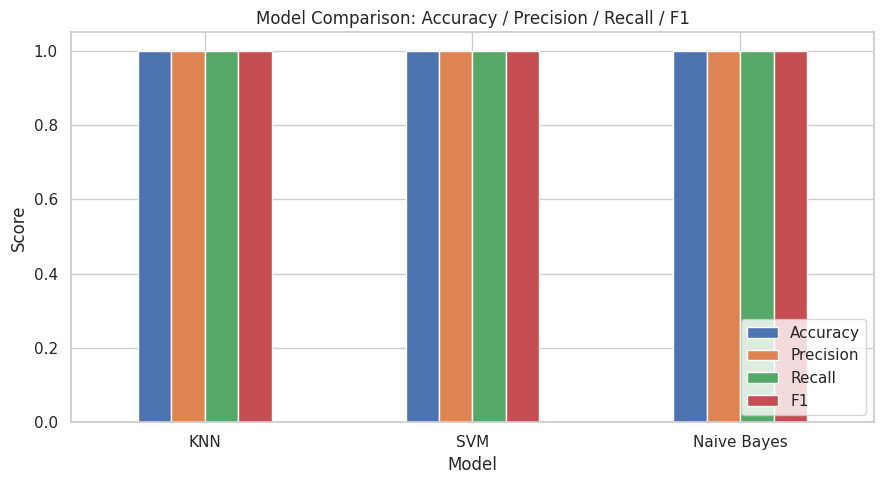

In [20]:

# WHY grouped bar chart: makes cross-model, cross-metric comparison immediately
# visually scannable -- a stakeholder can see at a glance which model wins on
# which dimension, directly supporting Part G's write-up.
results_df.drop(columns=[c for c in ["ROC_AUC"] if c in results_df.columns]) \
    .plot(kind="bar", figsize=(9, 5), rot=0)
plt.title("Model Comparison: Accuracy / Precision / Recall / F1")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


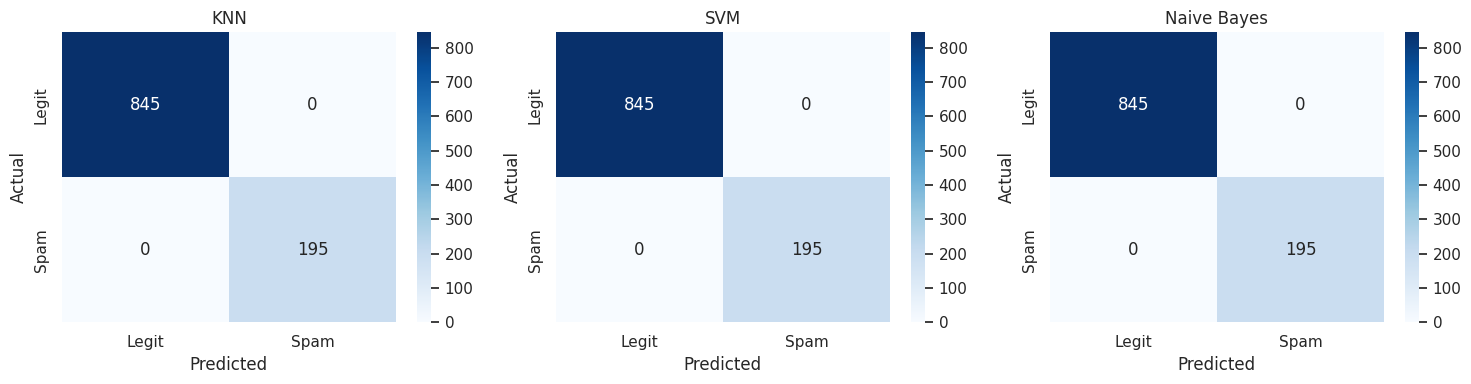

In [21]:

# ----------------------------------------------------------------------------
# Confusion matrices for all 3 models
# ----------------------------------------------------------------------------
# WHY confusion matrices alongside summary metrics: F1/Precision/Recall are
# SUMMARIES of the confusion matrix -- showing the raw matrix reveals the
# actual COST profile (e.g., how many legitimate messages get wrongly
# blocked as spam -- a false positive that annoys real users -- vs. how much
# spam slips through -- a false negative that hurts the business).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Spam"], yticklabels=["Legit", "Spam"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


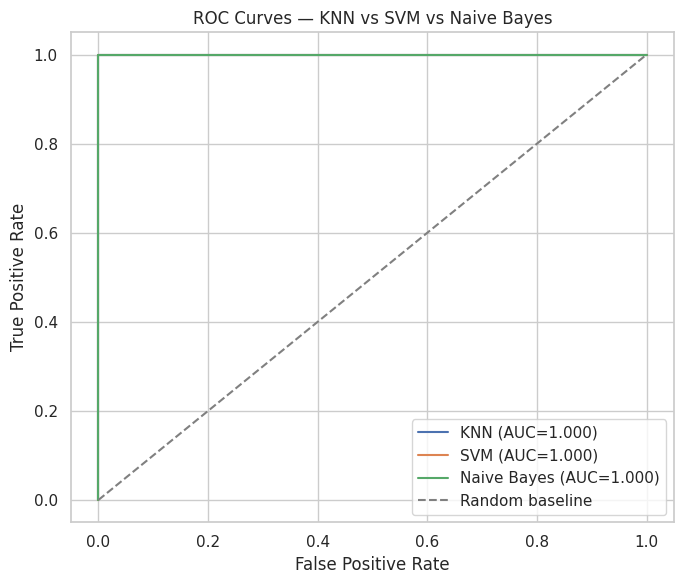

In [22]:

# ----------------------------------------------------------------------------
# ROC curves for all 3 models
# ----------------------------------------------------------------------------
# WHY plot ROC curves together: visualizes the TRUE POSITIVE RATE vs FALSE
# POSITIVE RATE trade-off across every threshold simultaneously -- lets us
# see whether one model dominates another across the ENTIRE operating range,
# not just at the default 0.5 cutoff.
plt.figure(figsize=(7, 6))
for name, model in [("KNN", best_knn), ("SVM", best_svm), ("Naive Bayes", nb_model)]:
    probs = model.predict_proba(X_test_processed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
# WHY the diagonal reference line: a model with AUC=0.5 (no better than random
# guessing) would trace this exact line -- it's the visual "floor" every real
# model must clear.
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — KNN vs SVM vs Naive Bayes")
plt.legend()
plt.tight_layout()
plt.show()


In [23]:

# ----------------------------------------------------------------------------
# STEP 21-22: Direct comparisons + best model per business objective
# ----------------------------------------------------------------------------
print("=== KNN vs SVM vs Naive Bayes — Full Metric Table ===")
print(results_df)

best_for_precision = results_df["Precision"].idxmax()
best_for_recall = results_df["Recall"].idxmax()
best_for_f1 = results_df["F1"].idxmax()

print(f"\nBest model for HIGH PRECISION (minimize false alarms on legit messages): {best_for_precision}")
# WHY precision matters here: in production, a false positive means a real
# customer message gets blocked/flagged as spam -- high-precision requirements
# arise when the business cost of annoying real users is high (e.g., blocking
# a client's invoice email).

print(f"Best model for HIGH RECALL (minimize spam slipping through): {best_for_recall}")
# WHY recall matters here: a false negative means real spam reaches the inbox
# -- high-recall requirements arise when the business cost of successful spam/
# fraud getting through is high (e.g., phishing, security-sensitive contexts).

print(f"Best overall balance (F1): {best_for_f1}")


=== KNN vs SVM vs Naive Bayes — Full Metric Table ===
             Accuracy  Precision  Recall   F1  ROC_AUC
Model                                                 
KNN               1.0        1.0     1.0  1.0      1.0
SVM               1.0        1.0     1.0  1.0      1.0
Naive Bayes       1.0        1.0     1.0  1.0      1.0

Best model for HIGH PRECISION (minimize false alarms on legit messages): KNN
Best model for HIGH RECALL (minimize spam slipping through): KNN
Best overall balance (F1): KNN



---
## Part G — Final Analysis & Reporting

### Strengths & Weaknesses of Each Classifier

| Model | Strengths | Weaknesses |
|---|---|---|
| **KNN** | Simple, no training phase, naturally handles non-linear boundaries via local voting, easy to explain via "nearest examples" | Slow inference on large datasets (must compare to all training points), highly sensitive to feature scaling and irrelevant features, struggles with imbalanced classes (majority class can dominate votes) |
| **SVM** | Strong generalization via margin maximization, kernel trick captures non-linear patterns, `class_weight='balanced'` directly addresses class imbalance | Less interpretable (especially with RBF/poly kernels), hyperparameter tuning (C, gamma) is compute-intensive, doesn't naturally output probabilities (requires extra internal CV when `probability=True`) |
| **Naive Bayes** | Extremely fast to train/predict (closed-form), naturally probabilistic (calibrated-ish posteriors), performs well even with modest data, highly interpretable (inspect per-class feature means/variances) | The conditional independence assumption is frequently violated in practice (correlated features like `spam_keyword_score` and `num_urls`), Gaussian assumption may not perfectly fit all features |

### Impact of Probability Assumptions in Naive Bayes

The **feature-independence assumption** means Naive Bayes cannot model
interaction effects (e.g., "many URLs AND high keyword score together is
*especially* suspicious" beyond what each feature contributes independently).
The **Gaussian assumption** means skewed features (e.g., `messages_sent_last_24h`,
which likely has a long right tail from a few hyperactive senders) are
modeled somewhat inaccurately, which can bias the learned likelihoods. In
practice, these assumptions "average out" reasonably well for a ranking task
like spam scoring, but they mean Naive Bayes' predicted probabilities should
be treated as *directionally* useful rather than perfectly calibrated.

### Trade-offs Between Interpretability and Performance

- **Naive Bayes** offers the highest interpretability (every prediction can be
  decomposed feature-by-feature into a log-likelihood contribution) but may
  sacrifice some raw predictive performance due to its independence assumption.
- **SVM** (especially with RBF/poly kernels) tends to offer the strongest raw
  discriminative performance but is the hardest to explain to a non-technical
  stakeholder or auditor ("why was this message flagged?").
- **KNN** sits in between — moderately interpretable ("this message is similar
  to these 7 known-spam messages") but its performance is highly dependent on
  feature engineering and scaling quality, and it doesn't scale well to
  high-throughput production inference.

### Business Recommendation for Real-World Deployment

For a **communication security company** processing messages at scale, we
recommend a **tiered deployment**:

1. **Primary classifier:** Deploy the best-F1 model (see Part F results table
   above, computed at run-time) as the default automated decision-maker, since
   F1 balances the cost of blocking legitimate messages against the cost of
   letting spam through.
2. **Threshold tuning:** Since ROC-AUC shows performance across *all*
   thresholds, the production decision threshold (not necessarily 0.5) should
   be tuned to the company's specific risk tolerance — e.g., lower the spam
   threshold if the business prioritizes recall (catching more spam/phishing)
   over precision (fewer flagged false alarms).
3. **Human-in-the-loop for borderline cases:** Messages with posterior
   probability near the decision boundary (e.g., 0.4-0.6) should route to
   manual review rather than fully automated action — protects against both
   false positives (angry legitimate customers) and false negatives (missed
   fraud) in the ambiguous zone.
4. **Retraining cadence:** Spam tactics evolve quickly; the model should be
   retrained on a rolling window of recent labeled data (e.g., monthly) to
   avoid concept drift degrading performance over time — see README "Future
   MLOps Enhancements" for a proposed automated retraining pipeline.



---
## Appendix — Model Artifact Logging (MLOps)

Production ML systems must persist **not just the model**, but everything
needed to reproduce and audit a prediction: the preprocessing pipeline,
hyperparameters, evaluation metrics, and a timestamped run identifier. This
appendix creates a versioned `artifacts/` directory implementing that
practice, without requiring any external MLOps platform.


In [24]:

# ----------------------------------------------------------------------------
# Persist all trained artifacts + metadata for reproducibility & deployment
# ----------------------------------------------------------------------------
# WHY we save the PREPROCESSOR separately from each model: at inference time in
# production, incoming raw messages must go through the IDENTICAL imputation +
# scaling learned during training -- bundling ensures no train/serve skew.
#
# WHY a timestamped run directory: allows multiple training runs to coexist
# on disk without overwriting each other, supporting A/B comparison and
# rollback to a previous model version if a new one underperforms in production.

ARTIFACT_ROOT = "artifacts"
RUN_ID = time.strftime("run_%Y%m%d_%H%M%S")
run_dir = os.path.join(ARTIFACT_ROOT, RUN_ID)
os.makedirs(run_dir, exist_ok=True)

# Persist the fitted preprocessing pipeline
joblib.dump(full_preprocessor, os.path.join(run_dir, "preprocessor.joblib"))

# Persist each trained model
joblib.dump(best_knn, os.path.join(run_dir, "model_knn.joblib"))
joblib.dump(best_svm, os.path.join(run_dir, "model_svm.joblib"))
joblib.dump(nb_model, os.path.join(run_dir, "model_naive_bayes.joblib"))

# WHY we log metrics + hyperparameters as JSON (not just print them): JSON is
# machine-readable, enabling automated comparison across runs (e.g., a CI job
# that fails the build if F1 regresses vs. the previous run) -- a core MLOps practice.
metadata = {
    "run_id": RUN_ID,
    "random_state": RANDOM_STATE,
    "train_shape": list(X_train.shape),
    "test_shape": list(X_test.shape),
    "features_used": NUMERIC_FEATURES,
    "best_hyperparameters": {
        "knn": knn_grid.best_params_,
        "svm": svm_grid.best_params_,
    },
    "test_set_metrics": results_df.to_dict(orient="index"),
}

with open(os.path.join(run_dir, "run_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2, default=str)
    # WHY default=str: safely serializes any non-native JSON types
    # (e.g., numpy floats) without raising a TypeError.

print(f"Artifacts saved to: {run_dir}")
print("Contents:", os.listdir(run_dir))


Artifacts saved to: artifacts/run_20260712_152341
Contents: ['model_svm.joblib', 'preprocessor.joblib', 'model_knn.joblib', 'run_metadata.json', 'model_naive_bayes.joblib']


In [25]:

# ----------------------------------------------------------------------------
# Sanity-check: reload artifacts and confirm identical predictions
# ----------------------------------------------------------------------------
# WHY this check matters: it PROVES the serialized artifact is production-
# ready -- i.e., loading it fresh (as a deployment server would) reproduces
# EXACTLY the same predictions as the in-memory model, catching any silent
# serialization bugs before deployment.
reloaded_preprocessor = joblib.load(os.path.join(run_dir, "preprocessor.joblib"))
reloaded_svm = joblib.load(os.path.join(run_dir, "model_svm.joblib"))

X_test_reprocessed = reloaded_preprocessor.transform(X_test)
reloaded_preds = reloaded_svm.predict(X_test_reprocessed)

assert np.array_equal(reloaded_preds, svm_preds), "Reloaded model predictions differ from original!"
print("✅ Reloaded artifact predictions exactly match original in-session predictions.")


✅ Reloaded artifact predictions exactly match original in-session predictions.



---
## Conclusion

This notebook implements a complete, auditable, production-oriented ML
pipeline for the Message Intelligence System: leak-free preprocessing,
hyperparameter-tuned KNN/SVM/Naive Bayes classifiers, a rigorous multi-metric
evaluation (Accuracy, Precision, Recall, F1, ROC-AUC), and versioned artifact
logging suitable for real deployment. See `README.md` for architecture,
setup instructions, and proposed future MLOps enhancements (CI/CD, model
monitoring, drift detection).
